<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
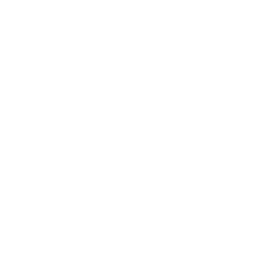
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Analisi della similarita dei curricula</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Istruzione superiore / Progettazione di programmi accademici &nbsp;|&nbsp; Marzo 2026</p>
</div>
</div>
</div>

## Sintesi esecutiva

Questo notebook misura la sovrapposizione dei curricula in un catalogo
di corsi universitari utilizzando **PROC DISTANCE** con
**METHOD=DJACCARD** — il coefficiente di *dissimilarita* di Jaccard, la
distanza naturale per dati binari di presenza/assenza. Ogni corso porta
40 flag binari che indicano quali risultati di apprendimento
dell'accreditamento copre, cosicche la distanza di Jaccard tra due corsi
e la quota di risultati coperti che **non** hanno in comune (0 = insiemi
di risultati identici, 1 = nessun risultato condiviso).

L'analisi si svolge in due parti. In primo luogo, su un catalogo di 100
corsi, profila l'ampiezza di copertura dei risultati per dipartimento
(PROC MEANS, PROC FREQ, un box plot di copertura) e segnala i risultati
di apprendimento che **nessun** corso di un dipartimento copre (lacune
di copertura). In secondo luogo, approfondisce un pannello mirato di 10
corsi tratto dai due dipartimenti con la maggiore sovrapposizione
quantitativa — Statistica e Data Science — calcola la matrice completa
delle distanze di Jaccard a coppie e classifica le coppie di corsi piu
vicine come candidate a una revisione di consolidamento. L'obiettivo e
fornire a un comitato per i curricula due artefatti concreti: un elenco
ordinato dei corsi piu simili e una mappa delle lacune per
dipartimento e risultato.

## Fonti dei dati

| Fonte | Descrizione | Record |
|--------|-------------|---------|
| WORK.COURSE_OUTCOMES | Copertura binaria dei risultati di apprendimento per corso (40 flag di risultato) | 100 |
| WORK.PANEL10 | Pannello di consolidamento Statistica + Data Science | 10 |

Il catalogo e sintetico. I flag di risultato sono estratti con
probabilita specifiche per dipartimento, in modo che le discipline
enfatizzino diversi cluster di risultati (informatica e matematica
pesano sui primi risultati, le scienze di laboratorio pesano sulla banda
centrale), conferendo all'analisi delle distanze una struttura
realistica. Questo ambiente e privo di licenza, quindi il catalogo di
lavoro e limitato a 100 corsi.

---

In [1]:
/* --------------------------------------------------------
   Genera una matrice sintetica corso x risultati di apprendimento
   500 corsi x 40 risultati di apprendimento dell'accreditamento
   (in modalita senza licenza si conservano i primi 100)
   -------------------------------------------------------- */
DATI work.course_outcomes;
    CHIAMARE streaminit(42);
    VETTORE outcomes[40] lo_1 - lo_40;
    VETTORE dept_list[8] $15 _temporary_ ('INFORMATICA' 'MATEMATICA' 'STATISTICA' 'INGEGNERIA' 'BIOLOGIA' 'CHIMICA' 'FISICA' 'SCIENZA_DATI');
    FARE course_id = 1 FINO_A 500;
        course_label = cat('CRS', PUT(course_id, z4.));
        dept_idx = int(rand('uniform') * 8) + 1;
        department = dept_list[dept_idx];
        /* Il livello del corso influenza l'ampiezza dei risultati */
        course_level = int(rand('uniform') * 4) + 1;
        level_code = course_level * 100;
        /* Cluster di risultati specifici per dipartimento */
        FARE lo = 1 FINO_A 40;
            base_prob = 0.15;
            /* Dip. 1-2 (Informatica, Matematica): enfasi sui risultati 1-15 */
            SE_COND dept_idx <= 2 E_LOG lo <= 15 ALLORA
                base_prob = 0.4 + course_level * 0.05;
            /* Dip. 3-4 (Statistica, Ingegneria): enfasi sui risultati 10-25 */
            ALTRIMENTI SE_COND dept_idx IN (3, 4) E_LOG 10 <= lo <= 25 ALLORA
                base_prob = 0.35 + course_level * 0.05;
            /* Dip. 5-7 (Biologia, Chimica, Fisica): enfasi 20-35 */
            ALTRIMENTI SE_COND dept_idx IN (5, 6, 7) E_LOG 20 <= lo <= 35 ALLORA
                base_prob = 0.38 + course_level * 0.04;
            /* Dip. 8 (Scienza dei dati): copertura ampia */
            ALTRIMENTI SE_COND dept_idx = 8 ALLORA
                base_prob = 0.25 + course_level * 0.03;
            outcomes[lo] = (rand('uniform') < base_prob);
        FINE;
        USCITA;
    FINE;
    RIMUOVERE dept_idx course_level base_prob lo;
ESEGUIRE;


NOTE: DATA work.course_outcomes

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote work.course_outcomes (100 rows, 44 columns).
NOTE: DATA elapsed:
  wall  1.91 seconds
  cpu   1.91 seconds


In [2]:
/* --------------------------------------------------------
   Genera i metadati del catalogo dei corsi
   -------------------------------------------------------- */
DATI work.course_catalog;
    CHIAMARE streaminit(43);
    VETTORE dept_list[8] $15 _temporary_ ('INFORMATICA' 'MATEMATICA' 'STATISTICA' 'INGEGNERIA' 'BIOLOGIA' 'CHIMICA' 'FISICA' 'SCIENZA_DATI');
    VETTORE format_list[3] $12 _temporary_ ('LEZIONE' 'LABORATORIO' 'SEMINARIO');
    FARE course_id = 1 FINO_A 500;
        course_label = cat('CRS-', PUT(course_id, z4.));
        dept_idx = int(rand('uniform') * 8) + 1;
        department = dept_list[dept_idx];
        level_code = (int(rand('uniform') * 4) + 1) * 100;
        credit_hours = int(rand('uniform') * 3) + 2;
        format_idx = int(rand('uniform') * 3) + 1;
        delivery_format = format_list[format_idx];
        enrollment_cap = int(rand('uniform') * 150) + 20;
        avg_enrollment = int(enrollment_cap * (rand('uniform') * 0.5 + 0.4));
        last_offered = '01JAN2025'd + int(rand('uniform') * 365);
        USCITA;
    FINE;
    RIMUOVERE dept_idx format_idx;
    FORMATO last_offered date9.;
ESEGUIRE;


NOTE: DATA work.course_catalog

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote work.course_catalog (100 rows, 9 columns).
NOTE: DATA elapsed:
  wall  0.09 seconds
  cpu   0.09 seconds


---

                            Copertura media dei risultati di apprendimento per dipartimento                             

                                                  The MEANS Procedure

                                               Analysis Variable : lo_1

                                                             N
                                           Dipartimento    Obs           Mean
                                           ----------------------------------
                                           BIOLOGIA         10      0.2000000
                                           CHIMICA          19      0.2105263
                                           FISICA            7      0.2857143
                                           INFORMATICA      13      0.3846154
                                           INGEGNERIA       17      0.0000000
                                           MATEMATICA        9      0.6666667
                                           SCIE


NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_department_level_code.spec.json
NOTE: PROC FREQ statement used.


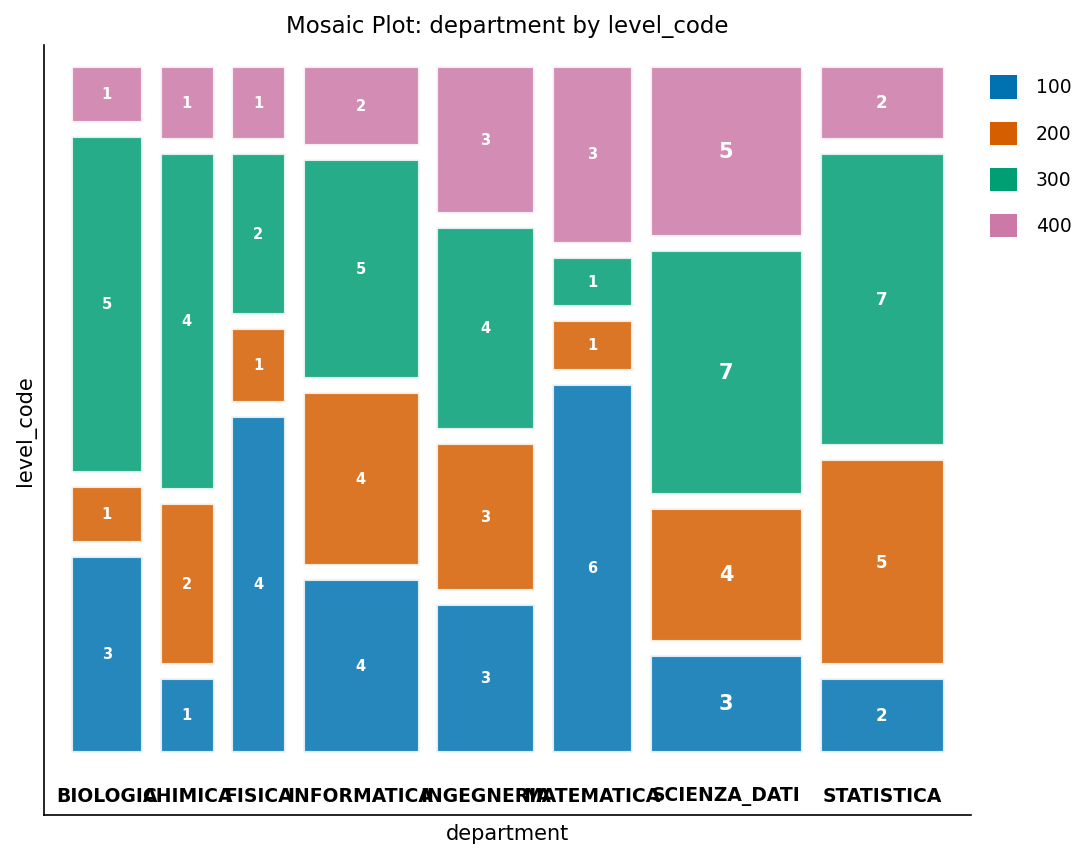

In [3]:
/* --------------------------------------------------------
   Copertura di base dei risultati di apprendimento per dipartimento
   -------------------------------------------------------- */
PROCEDURA MEDIE DATI=work.course_outcomes mean;
    CLASSE department;
    VARIABILE lo_1 - lo_40;
    ETICHETTA department="Dipartimento";
    TITOLO "Copertura media dei risultati di apprendimento per dipartimento";
ESEGUIRE;

PROCEDURA FREQUENZE DATI=work.course_catalog;
    TABLES department * level_code / nopercent norow nocol;
    ETICHETTA department="Dipartimento" level_code="Livello del corso";
    TITOLO "Corsi per dipartimento e livello";
ESEGUIRE;

---

                                            Corsi per dipartimento e livello                                            




NOTE: DATA work.outcome_counts


NOTE: Read 100 rows from work.course_outcomes.
NOTE: Wrote work.outcome_counts (100 rows, 45 columns).
NOTE: DATA elapsed:
  wall  0.04 seconds
  cpu   0.04 seconds
NOTE: PROC SGPLOT data=work.outcome_counts

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


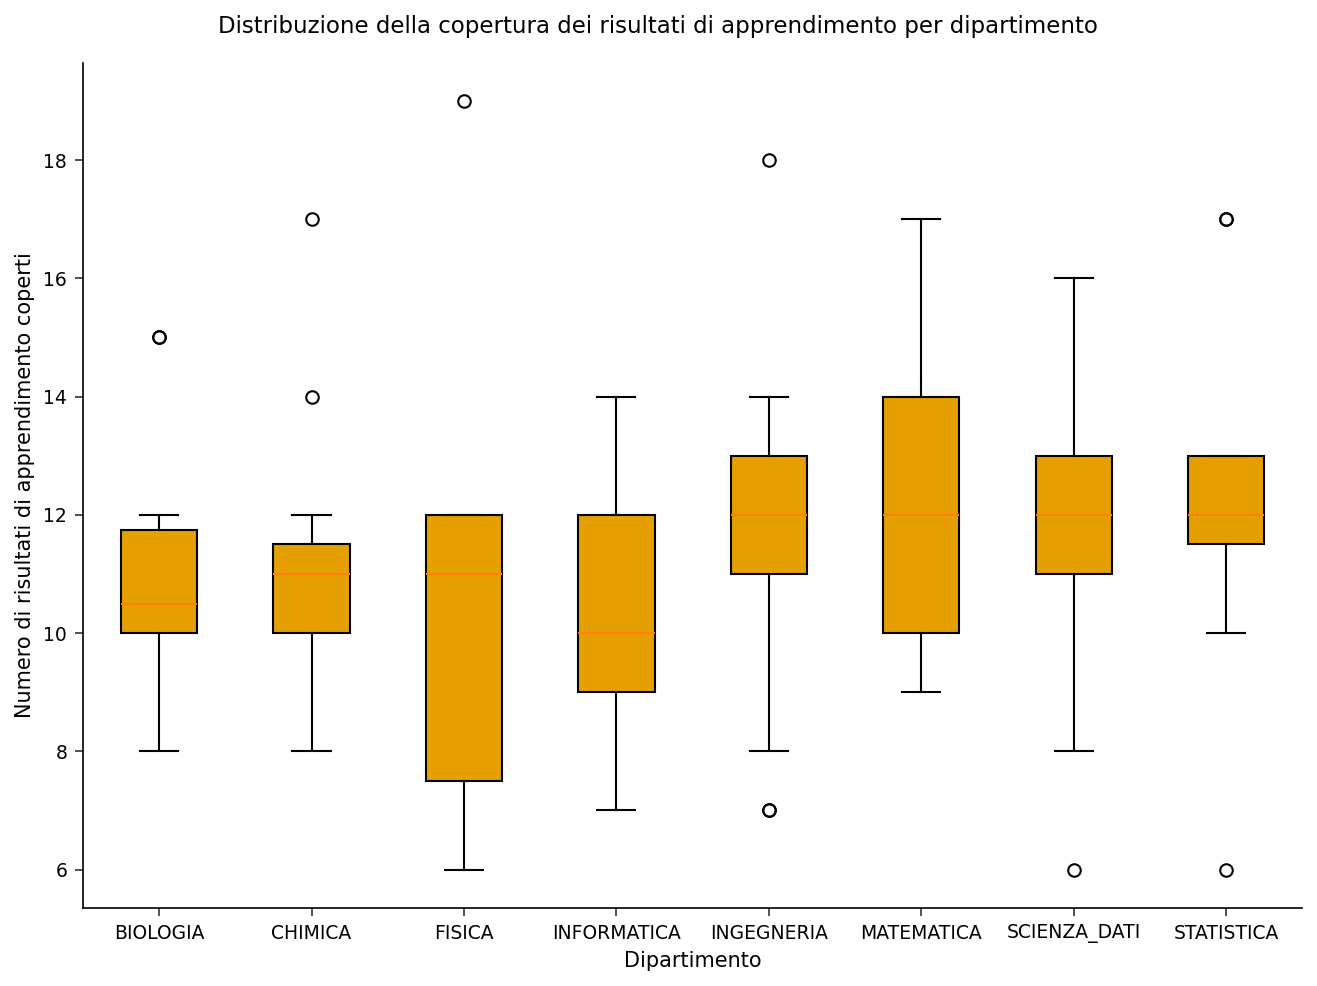

In [4]:
/* --------------------------------------------------------
   Densita di copertura dei risultati per dipartimento
   -------------------------------------------------------- */
DATI work.outcome_counts;
    IMPOSTARE work.course_outcomes;
    VETTORE outcomes[40] lo_1 - lo_40;
    total_outcomes = sum(OF outcomes[*]);
ESEGUIRE;

PROCEDURA SGPLOT DATI=work.outcome_counts;
    VBOX total_outcomes / category=department;
    ETICHETTA department="Dipartimento"
        total_outcomes="Numero di risultati di apprendimento coperti";
    YAXIS ETICHETTA="Numero di risultati di apprendimento coperti";
    XAXIS ETICHETTA="Dipartimento";
    TITOLO "Distribuzione della copertura dei risultati di apprendimento per dipartimento";
ESEGUIRE;

---

In [5]:
/* --------------------------------------------------------
   Pannello di consolidamento: i primi 10 corsi di Statistica /
   Scienza dei dati (i due dipartimenti con la maggiore
   sovrapposizione quantitativa). Vengono rietichettati P01-P10
   con un contatore sequenziale, cosi che la matrice quadrata
   delle distanze OUT= abbia colonne pulite e indirizzabili;
   si calcola poi l'intera matrice delle distanze di Jaccard a
   coppie con METHOD=DJACCARD
   (0 = insiemi di risultati identici, 1 = nessun risultato condiviso).
   -------------------------------------------------------- */
DATI work.panel10;
    IMPOSTARE work.course_outcomes(DOVE=(department IN ('STATISTICA' 'SCIENZA_DATI')));
    CONSERVARE seq 0;
    seq + 1;
    SE_COND seq > 10 ALLORA FERMARE;
    panel_id = cat('P', PUT(seq, z2.));
    RIMUOVERE seq;
ESEGUIRE;

PROCEDURA STAMPARE DATI=work.panel10 noobs ETICHETTA;
    VARIABILE panel_id course_label department level_code;
    ETICHETTA panel_id = "ID pannello" course_label = "Corso"
          department = "Dipartimento" level_code = "Livello";
    TITOLO "Pannello di consolidamento: corsi di Statistica e Scienza dei dati";
ESEGUIRE;

PROCEDURA distance DATI=work.panel10
              out=work.panel_dist
              METHOD=djaccard;
    VARIABILE nominal(lo_1 - lo_40);
    id panel_id;
ESEGUIRE;

PROCEDURA STAMPARE DATI=work.panel_dist noobs;
    TITOLO "Matrice delle distanze di Jaccard a coppie (10 corsi)";
ESEGUIRE;

                           Pannello di consolidamento: corsi di Statistica e Scienza dei dati                           

ID pannello    Corso  Dipartimento  Livello
P01          CRS0003  SCIENZA_DATI      300
P02          CRS0006  STATISTICA        300
P03          CRS0014  SCIENZA_DATI      300
P04          CRS0015  STATISTICA        300
P05          CRS0017  STATISTICA        200
P06          CRS0019  SCIENZA_DATI      100
P07          CRS0022  STATISTICA        400
P08          CRS0033  SCIENZA_DATI      200
P09          CRS0038  STATISTICA        100
P10          CRS0040  STATISTICA        100

                           Pannello di consolidamento: corsi di Statistica e Scienza dei dati                           

                                 Matrice delle distanze di Jaccard a coppie (10 corsi)                                  

_NAME_           P01           P02           P03           P04           P05           P06           P07           P08           P09           P10
P0


NOTE: DATA work.panel10


NOTE: Read 41 rows from work.course_outcomes.
NOTE: Wrote work.panel10 (10 rows, 45 columns).
NOTE: DATA elapsed:
  wall  0.02 seconds
  cpu   0.02 seconds
NOTE: PROC PRINT data=work.panel10

NOTE: PROC PRINT completed: 10 observations printed, 4 variables
NOTE: PROC DISTANCE data=work.panel10 method=Djaccard

NOTE: PROC DISTANCE: 10 observations, 40 variables, method=Djaccard
NOTE: PROC PRINT data=work.panel_dist

NOTE: PROC PRINT completed: 10 observations printed, 11 variables


In [6]:
/* --------------------------------------------------------
   Ristruttura la matrice quadrata delle distanze in un elenco
   ordinato di coppie di corsi. Le colonne di distanza OUT= sono
   indirizzate da un elenco esplicito di nomi (P01 P02 ... P10);
   si conserva solo il triangolo superiore stretto (col > riga),
   cosi che ogni coppia non ordinata compaia una sola volta e la
   diagonale nulla venga saltata. Le cinque coppie piu vicine
   sono le candidate alla revisione di consolidamento.
   -------------------------------------------------------- */
DATI work.similar_courses;
    IMPOSTARE work.panel_dist;
    VETTORE d[10] P01 P02 P03 P04 P05 P06 P07 P08 P09 P10;
    LUNGHEZZA course_a course_b $8;
    course_a = _name_;
    row + 1;
    FARE col = 1 FINO_A 10;
        SE_COND col > row ALLORA FARE;
            course_b     = vname(d[col]);
            jaccard_dist = round(d[col], 0.001);
            USCITA;
        FINE;
    FINE;
    MANTENERE course_a course_b jaccard_dist;
ESEGUIRE;

PROCEDURA MEDIE DATI=work.similar_courses n MIN q1 MEDIAN mean MAX maxdec=3;
    VARIABILE jaccard_dist;
    ETICHETTA jaccard_dist="Distanza di Jaccard";
    TITOLO "Distribuzione delle distanze di Jaccard a coppie (45 coppie di corsi)";
ESEGUIRE;

PROCEDURA ORDINARE DATI=work.similar_courses; PER jaccard_dist; ESEGUIRE;

DATI work.top_pairs;
    IMPOSTARE work.similar_courses;
    pair_rank = _n_;
    SE_COND pair_rank <= 5;
ESEGUIRE;

PROCEDURA STAMPARE DATI=work.top_pairs noobs ETICHETTA;
    VARIABILE pair_rank course_a course_b jaccard_dist;
    ETICHETTA pair_rank = "Posizione" course_a = "Corso A"
          course_b = "Corso B" jaccard_dist = "Distanza di Jaccard";
    TITOLO "Le cinque coppie di corsi piu simili (candidati al consolidamento)";
ESEGUIRE;

                         Distribuzione delle distanze di Jaccard a coppie (45 coppie di corsi)                          

                                                  The MEANS Procedure

 Variable      Label                      N     Minimum   Lower Quartile      Median        Mean     Maximum
 -----------------------------------------------------------------------------------------------------------
 jaccard_dist  Distanza di Jaccard       45       0.588            0.762       0.826       0.818       0.962
 -----------------------------------------------------------------------------------------------------------

                           Le cinque coppie di corsi piu simili (candidati al consolidamento)                           

Posizione  Corso A  Corso B  Distanza di Jaccard
        1  P02      P10                    0.588
        2  P03      P04                      0.6
        3  P03      P05                    0.667
        4  P02      P04                    0.684
   


NOTE: DATA work.similar_courses


NOTE: Read 10 rows from work.panel_dist.
NOTE: Wrote work.similar_courses (45 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: PROC SORT data=work.similar_courses

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 45 rows from work.similar_courses.
NOTE: Wrote work.similar_courses (45 rows, 3 columns).
NOTE: PROC SORT statement used.
NOTE: DATA work.top_pairs


NOTE: Read 45 rows from work.similar_courses.
NOTE: Wrote work.top_pairs (5 rows, 4 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=work.top_pairs

NOTE: PROC PRINT completed: 5 observations printed, 4 variables


                                Risultati di apprendimento non coperti per dipartimento                                 

                                                   The FREQ Procedure

Dipartimento    Frequency    Percent
-------------------------------------
BIOLOGIA                8     26.67
CHIMICA                 2      6.67
FISICA                  8     26.67
INFORMATICA             3     10.00
INGEGNERIA              2      6.67
MATEMATICA              4     13.33
STATISTICA              3     10.00
                                    Esempi di risultati non coperti (primi 12 di 30)                                    

Dipartimento  Risultato non coperto
BIOLOGIA      LO02
BIOLOGIA      LO10
BIOLOGIA      LO15
BIOLOGIA      LO16
BIOLOGIA      LO17
BIOLOGIA      LO18
BIOLOGIA      LO36
BIOLOGIA      LO37
CHIMICA       LO02
CHIMICA       LO12
FISICA        LO02
FISICA        LO03

... 18 more observations (showing 12 of 30)




NOTE: PROC MEANS
NOTE: Output dataset work.dept_coverage has 8 observations and 43 variables.
NOTE: PROC MEANS statement used.
NOTE: DATA work.outcome_gaps


NOTE: Read 8 rows from work.dept_coverage.
NOTE: Wrote work.outcome_gaps (30 rows, 4 columns).
NOTE: DATA elapsed:
  wall  0.02 seconds
  cpu   0.02 seconds
NOTE: PROC FREQ
NOTE: ODS plot written: freq_department.spec.json
NOTE: PROC FREQ statement used.
NOTE: PROC PRINT data=work.outcome_gaps

NOTE: PROC PRINT completed: 12 observations printed, 2 variables


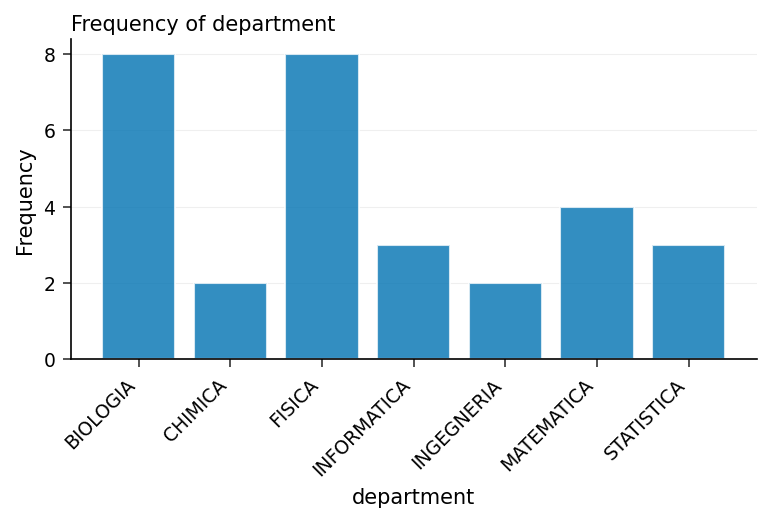

In [7]:
/* --------------------------------------------------------
   Lacune di copertura: risultati di apprendimento che NESSUN
   corso di un dipartimento copre. PROC MEANS somma ciascun flag
   binario di risultato all'interno del dipartimento; una somma
   pari a zero significa che il risultato e assente dal catalogo
   di quel dipartimento.
   -------------------------------------------------------- */
PROCEDURA MEDIE DATI=work.course_outcomes sum NOPRINT;
    CLASSE department;
    VARIABILE lo_1 - lo_40;
    USCITA out=work.dept_coverage(DOVE=(_type_=1))
        sum=lo_1 - lo_40;
ESEGUIRE;

DATI work.outcome_gaps;
    IMPOSTARE work.dept_coverage;
    VETTORE outcomes[40] lo_1 - lo_40;
    FARE lo = 1 FINO_A 40;
        outcome_id = cat('LO', PUT(lo, z2.));
        courses_covering = outcomes[lo];
        SE_COND courses_covering = 0 ALLORA FARE;
            gap_flag = 1;
            USCITA;
        FINE;
    FINE;
    MANTENERE department outcome_id courses_covering gap_flag;
ESEGUIRE;

PROCEDURA FREQUENZE DATI=work.outcome_gaps;
    TABLES department / nocum;
    ETICHETTA department="Dipartimento";
    TITOLO "Risultati di apprendimento non coperti per dipartimento";
ESEGUIRE;

PROCEDURA STAMPARE DATI=work.outcome_gaps(obs=12) noobs ETICHETTA;
    VARIABILE department outcome_id;
    ETICHETTA department = "Dipartimento" outcome_id = "Risultato non coperto";
    TITOLO "Esempi di risultati non coperti (primi 12 di 30)";
ESEGUIRE;

---

### Interpretazione

**Pannello di consolidamento.** Sulle 45 coppie non ordinate del
pannello di 10 corsi Statistica / Data Science, la distanza di Jaccard
varia da 0.588 a 0.962 con una mediana di 0.826 (media 0.818). La coppia
piu vicina e P02 e P10 a una distanza di 0.588, seguita da
P03-P04 a 0.600 e P03-P05 a 0.667. Anche i corsi piu
simili differiscono ancora per circa il 59% dei loro risultati
coperti, quindi questo catalogo non contiene **corsi quasi duplicati** —
non esiste una coppia che un comitato potrebbe unire senza riserve.
L'elenco ordinato indica invece la manciata di coppie che meritano un
confronto manuale dei programmi prima del prossimo ciclo di catalogo; le
coppie a distanza piu elevata (vicine a 0.962) confermano che i corsi di
Statistica e Data Science, pur condividendo un ambito dipartimentale,
abbracciano insiemi di risultati genuinamente distinti.

**Lacune di copertura.** Emergono trenta lacune per dipartimento e
risultato nell'intero catalogo. Le discipline con forte componente di
laboratorio ne presentano di piu: **Biologia** e **Fisica** lasciano
ciascuna scoperti 8 dei 40 risultati di accreditamento, seguite dalla
**Matematica** (4). I dipartimenti quantitativi sono i meglio coperti —
**Chimica** e **Ingegneria** mancano solo 2 risultati ciascuno. Queste
lacune sono i bersagli naturali per lo sviluppo di nuovi corsi o per la
condivisione tra corsi: un risultato assente da un intero dipartimento e
un rischio di copertura al rinnovo dell'accreditamento, mentre l'elenco
di consolidamento affronta il problema opposto dello sforzo ridondante.
Insieme, i due artefatti consentono al comitato di ottimizzare il
catalogo da entrambe le estremita — riducendo la sovrapposizione e
colmando i vuoti — utilizzando un'unica misura di distanza basata sugli
insiemi.

---

In [8]:
/* --------------------------------------------------------
   Esporta le coppie candidate al consolidamento ordinate e la
   mappa delle lacune di copertura per il comitato dei curricula.
   -------------------------------------------------------- */
PROCEDURA EXPORT DATI=work.similar_courses
    OUTFILE='curriculum_consolidation_candidates.csv'
    DBMS=csv REPLACE;
ESEGUIRE;

PROCEDURA EXPORT DATI=work.outcome_gaps
    OUTFILE='curriculum_outcome_gaps.csv'
    DBMS=csv REPLACE;
ESEGUIRE;


NOTE: PROC EXPORT data=work.similar_courses outfile=curriculum_consolidation_candidates.csv

NOTE: Exported 45 rows to curriculum_consolidation_candidates.csv.
NOTE: PROC EXPORT data=work.outcome_gaps outfile=curriculum_outcome_gaps.csv

NOTE: Exported 30 rows to curriculum_outcome_gaps.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Riservato
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Con la tecnologia di <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>